In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_preds = pd.read_excel('dados_resultado\\relatorio_risco_churn_xgb_tuning_2026-06-26.xlsx')
df_preds

,cod_cliente,valor_medio_contrato,meses_vida_cliente,qt_tarefas_total,media_dias_exec,qt_tarefas_sd,media_dias_exec_tarefa_sd,perc_qt_tarefas_sd,qt_tarefas_hd,media_dias_exec_tarefa_hd,...,qt_categorias_distintas,qt_subcategorias_distintas,qt_grupos_envolvidos,perc_qt_prioridade_normal,perc_qt_prioridade_parcial,perc_qt_prioridade_urgente,perc_qt_prioridade_maxima,perc_qt_prioridade_reforco,churn,risco_churn_percentual
0,46821,283.69,4,8,4.0,0,0.0000,0.00000,8,4.0000,...,1,4,2,100.00000,0.00000,0.00000,0.00000,0.00000,0,0.97
1,18431,377.16,33,9,10.7,0,0.0000,0.00000,3,7.0000,...,6,9,5,100.00000,0.00000,0.00000,0.00000,0.00000,0,0.92
2,46520,330.00,10,3,21.7,0,0.0000,0.00000,1,1.0000,...,3,3,2,100.00000,0.00000,0.00000,0.00000,0.00000,0,0.92
3,13533,133.23,27,13,17.3,0,0.0000,0.00000,6,7.5000,...,8,11,4,100.00000,0.00000,0.00000,0.00000,0.00000,0,0.91
4,45135,513.56,38,9,22.4,0,0.0000,0.00000,3,8.6667,...,6,9,6,100.00000,0.00000,0.00000,0.00000,0.00000,0,0.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1841,15951,12808.44,212,1104,28.9,105,40.9898,9.51087,331,10.4073,...,63,163,29,90.76087,0.90580,4.16667,3.71377,0.45290,0,0.02
1842,12449,3276.58,211,411,13.0,27,11.8148,6.56934,239,2.6920,...,36,65,25,96.35036,1.21655,1.45985,0.97324,0.00000,0,0.02
1843,175,38283.23,331,1670,11.3,70,14.7059,4.19162,355,5.8475,...,51,149,27,93.65269,0.71856,2.27545,1.97605,1.37725,0,0.02
1844,38998,2706.61,100,291,7.8,20,10.9000,6.87285,161,2.4151,...,29,75,20,91.75258,2.74914,3.43643,2.06186,0.00000,0,0.02


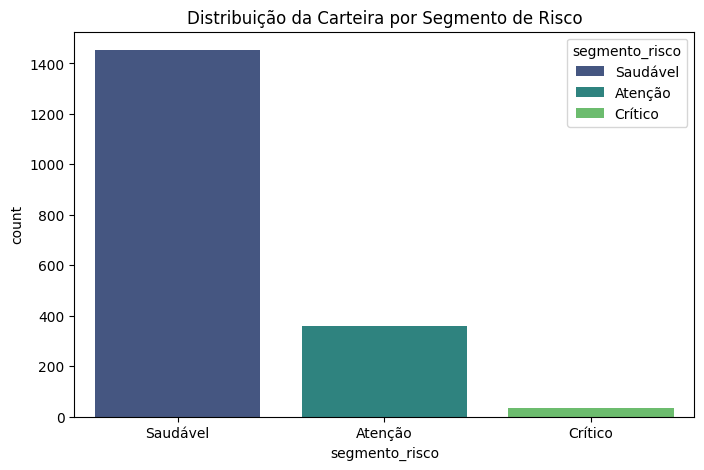

In [9]:
# Criando categorias de risco
bins = [0, 0.3, 0.7, 1.0]
labels = ['Saudável', 'Atenção', 'Crítico']
df_preds['segmento_risco'] = pd.cut(df_preds['risco_churn_percentual'], bins=bins, labels=labels, include_lowest=True)

# Visualizando quantos clientes estão em cada grupo
plt.figure(figsize=(8, 5))
sns.countplot(x='segmento_risco', data=df_preds, palette='viridis', hue='segmento_risco', legend=True)
plt.title('Distribuição da Carteira por Segmento de Risco')
plt.show()

In [39]:
# Comparando médias das colunas principais entre Críticos e Saudáveis
analise_drivers = df_preds.groupby('segmento_risco', observed=True)[df_preds.drop(columns=['risco_churn_percentual', 'churn', 'segmento_risco']).columns].mean()
analise_drivers

,cod_cliente,valor_medio_contrato,meses_vida_cliente,qt_tarefas_total,media_dias_exec,qt_tarefas_sd,media_dias_exec_tarefa_sd,perc_qt_tarefas_sd,qt_tarefas_hd,media_dias_exec_tarefa_hd,...,media_dias_exec_bug,perc_qt_tarefas_bug,qt_categorias_distintas,qt_subcategorias_distintas,qt_grupos_envolvidos,perc_qt_prioridade_normal,perc_qt_prioridade_parcial,perc_qt_prioridade_urgente,perc_qt_prioridade_maxima,perc_qt_prioridade_reforco
segmento_risco,,,,,,,,,,,,,,,,,,,,,
Saudável,30103.105988,2677.928864,89.441156,181.229181,15.358637,14.899518,9.463264,6.296931,92.946318,3.601094,...,16.970472,1.180555,17.378527,34.945630,12.715760,91.407647,1.591394,4.787239,2.141428,0.072292
Atenção,35354.150418,986.263593,48.055710,31.565460,24.950975,2.172702,4.501723,5.146502,14.008357,3.580052,...,5.686507,1.095071,8.657382,12.924791,7.019499,95.193030,0.618842,2.124451,2.034179,0.029497
Crítico,35179.735294,467.309412,29.029412,12.176471,21.635294,0.941176,3.818626,5.580155,4.588235,6.580376,...,1.450979,2.034314,6.294118,8.029412,4.852941,96.250269,0.323206,1.253322,2.173203,0.000000


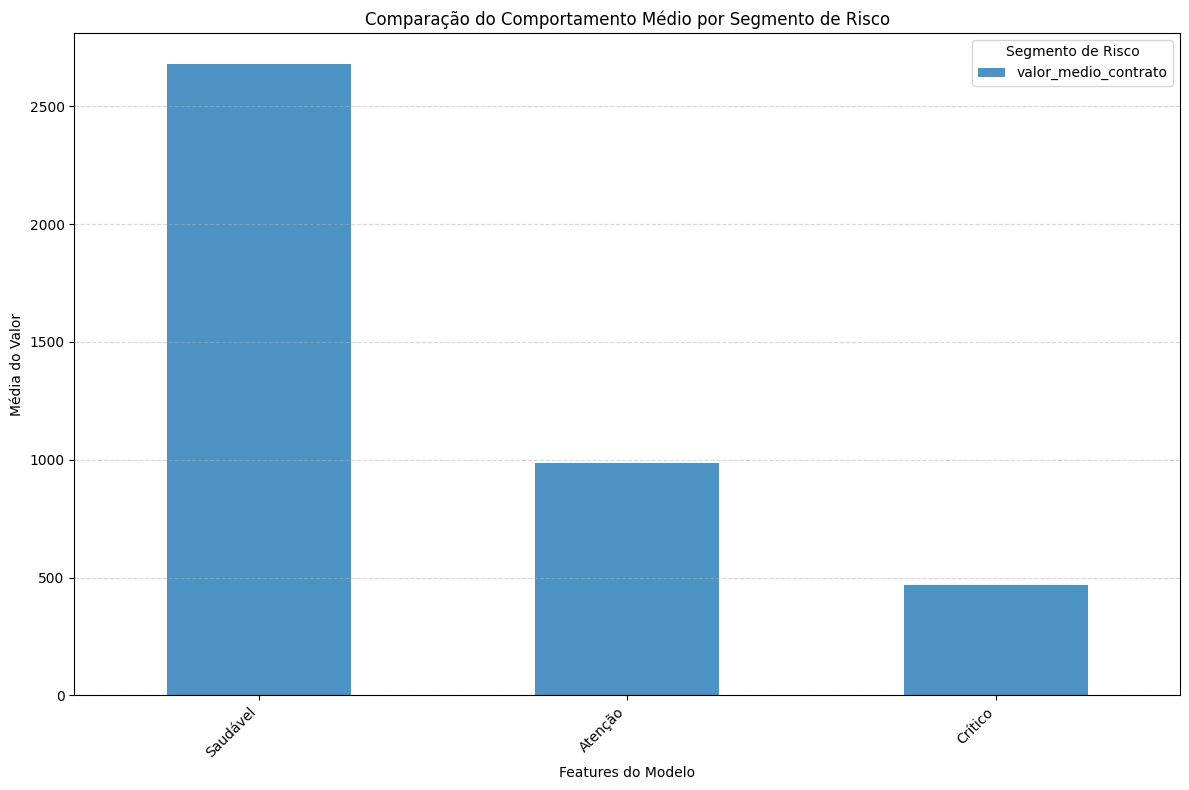

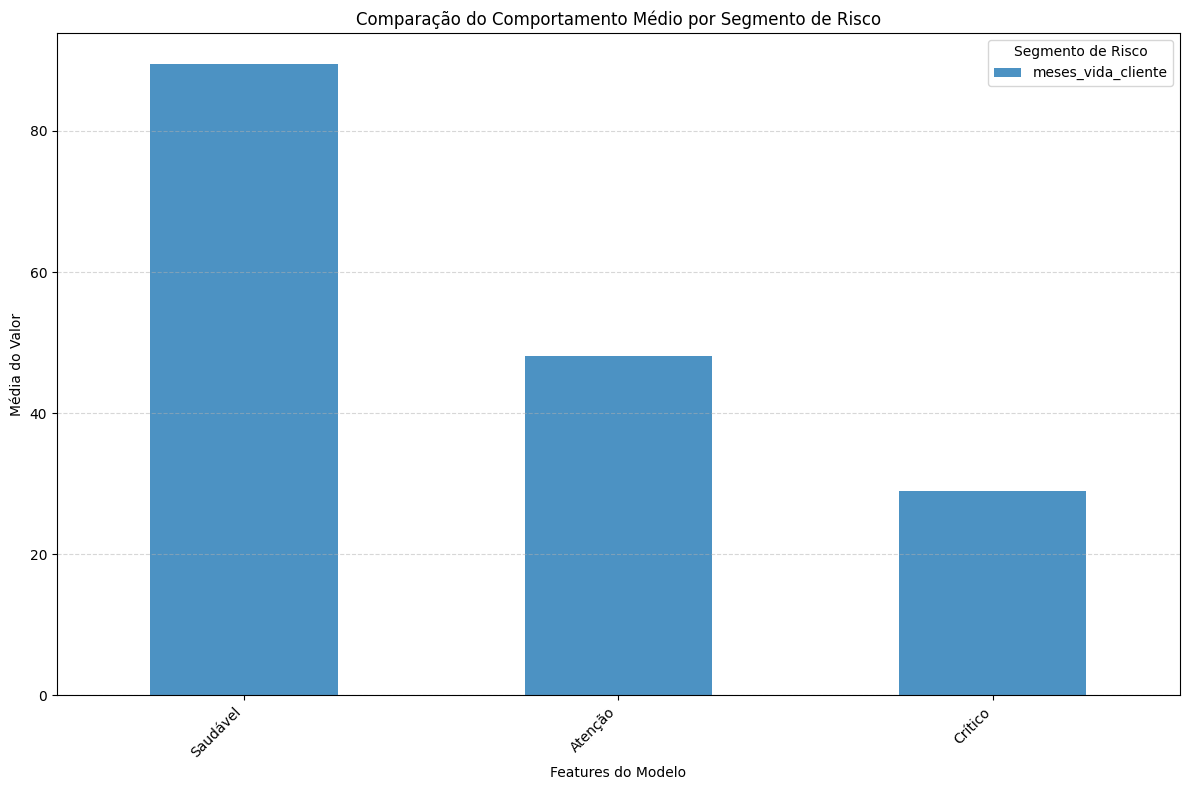

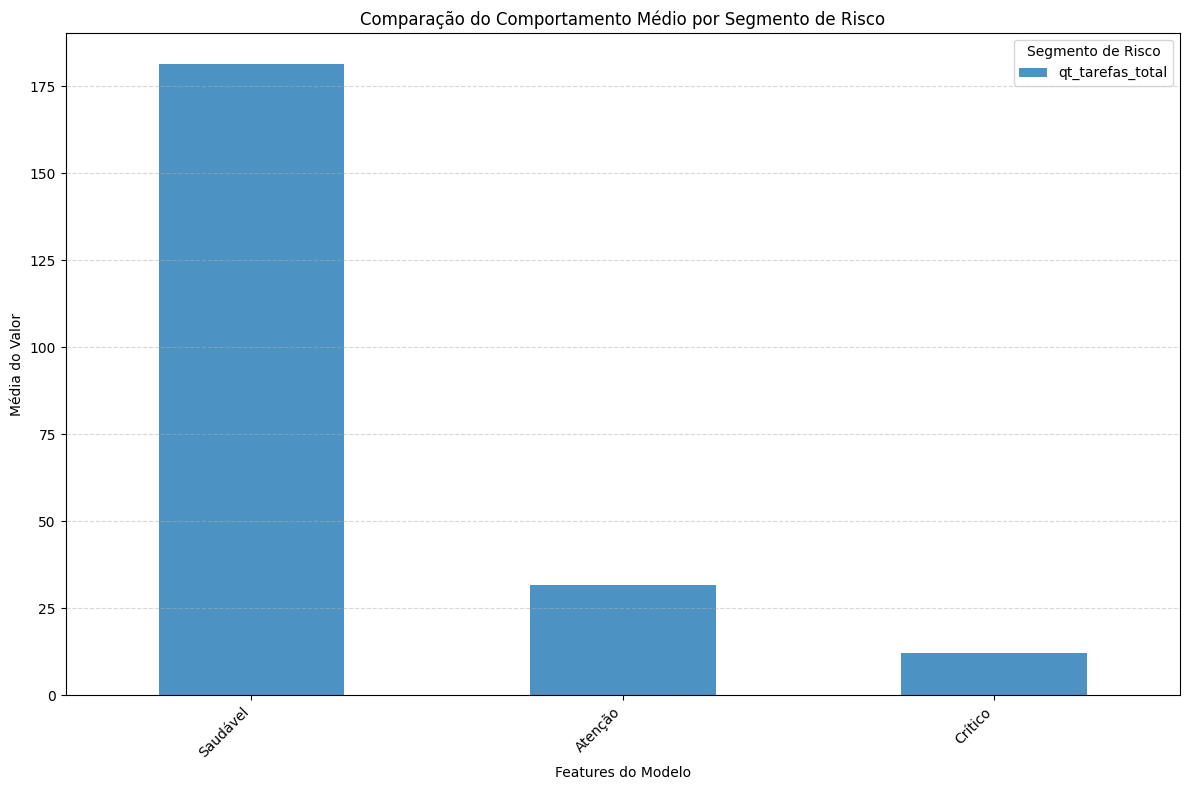

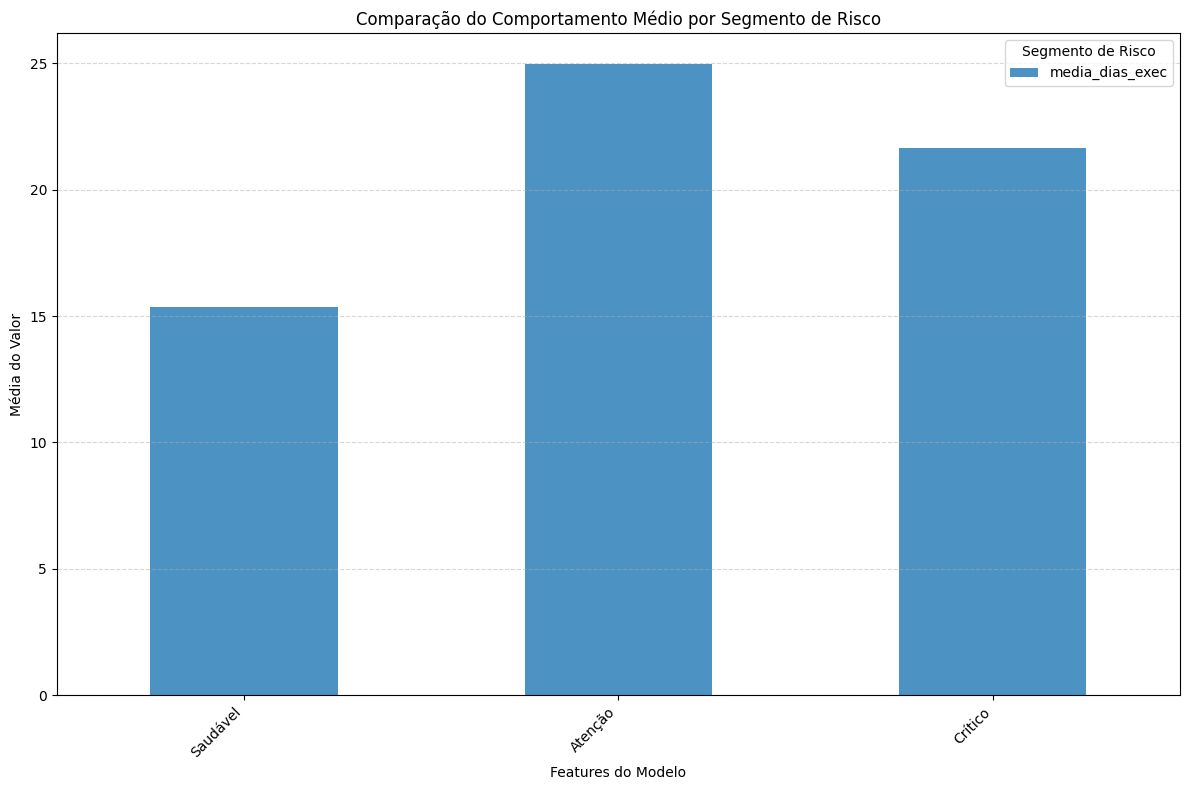

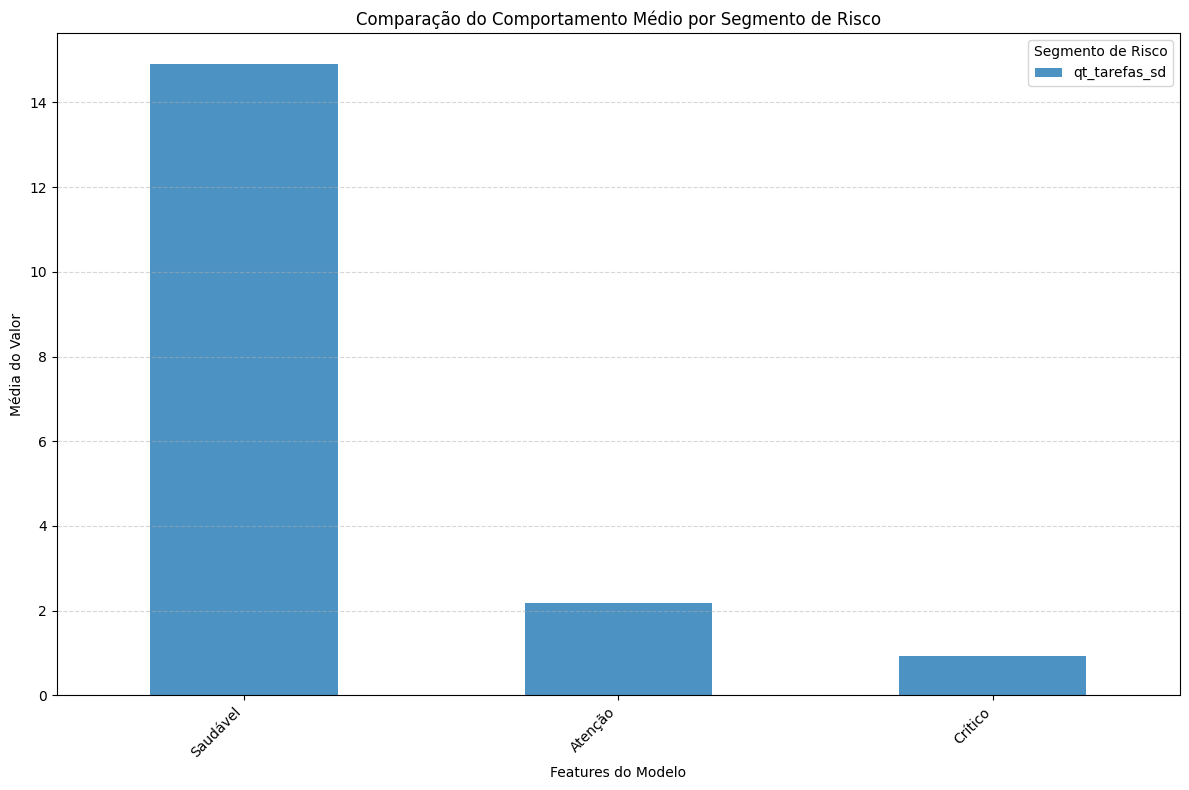

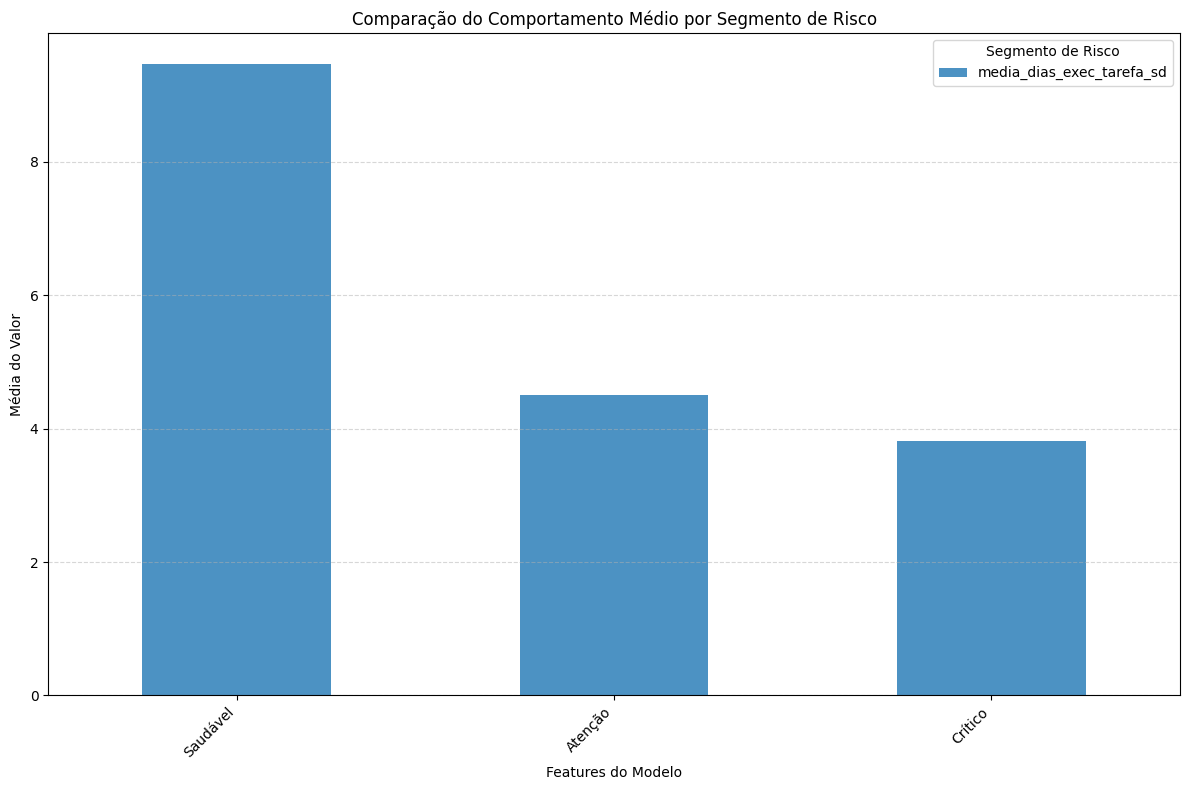

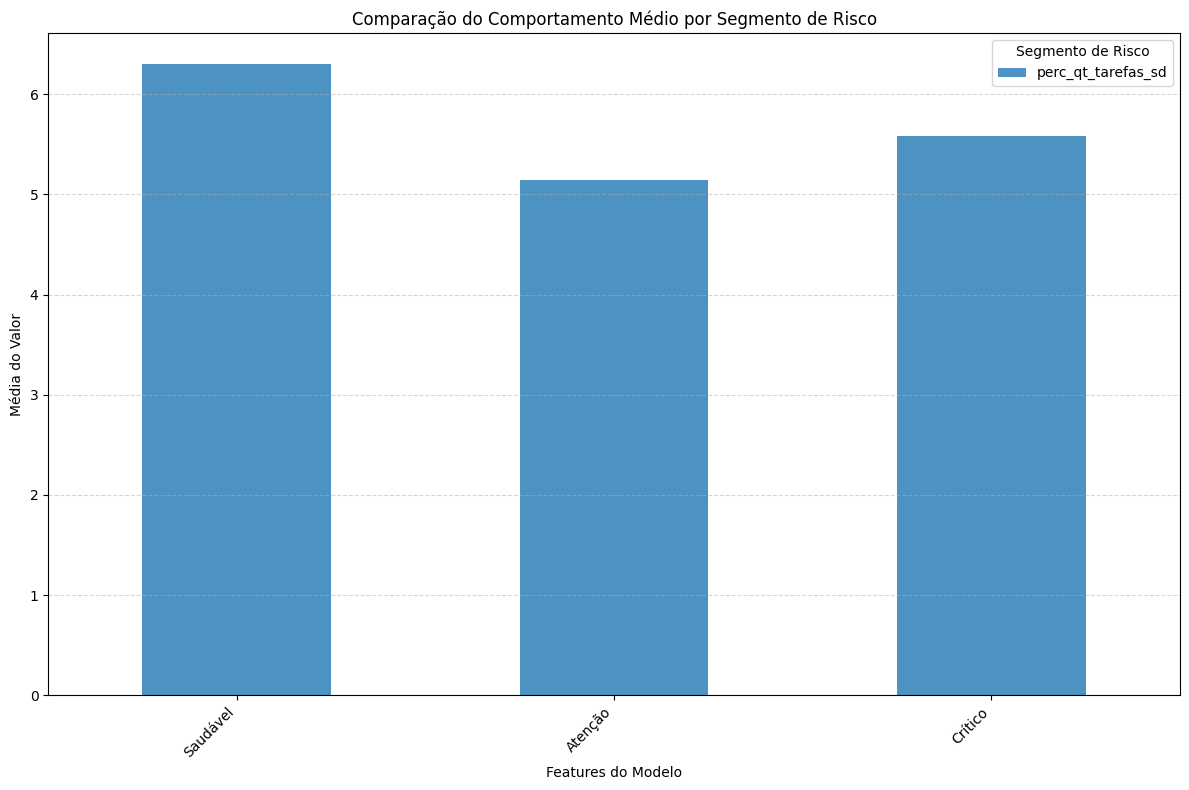

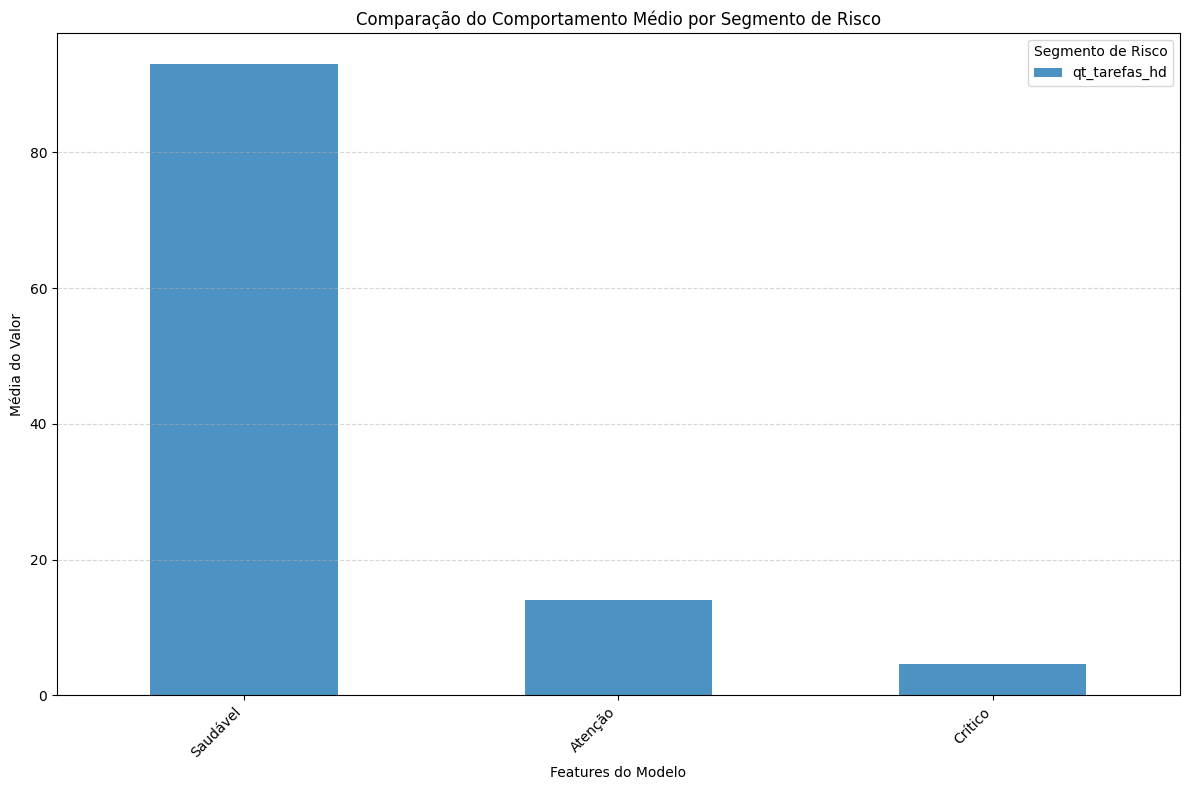

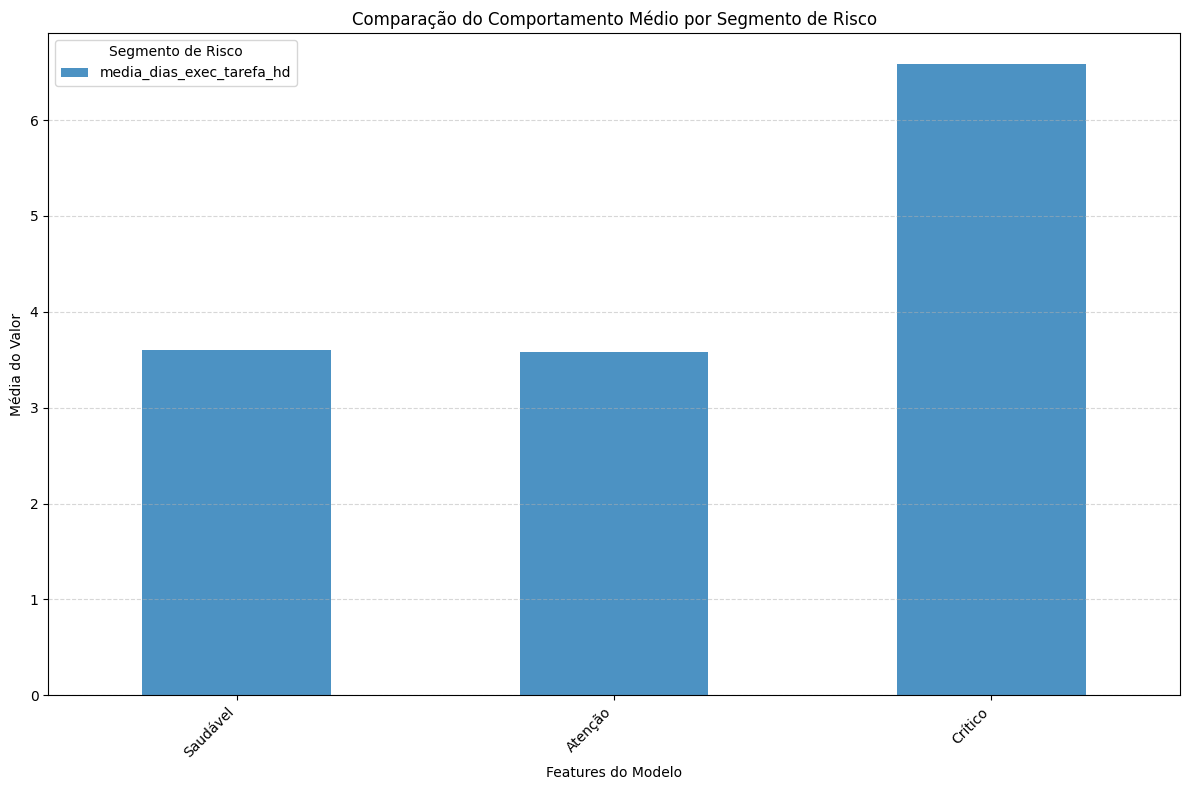

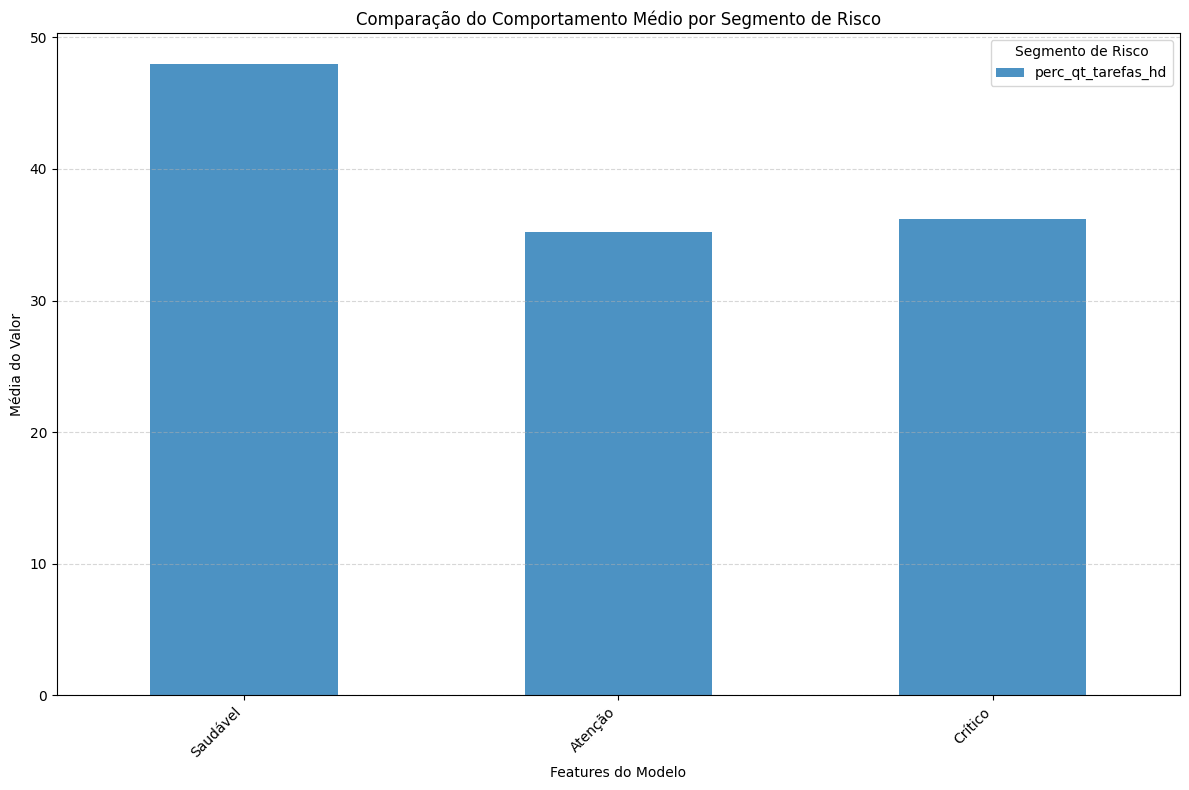

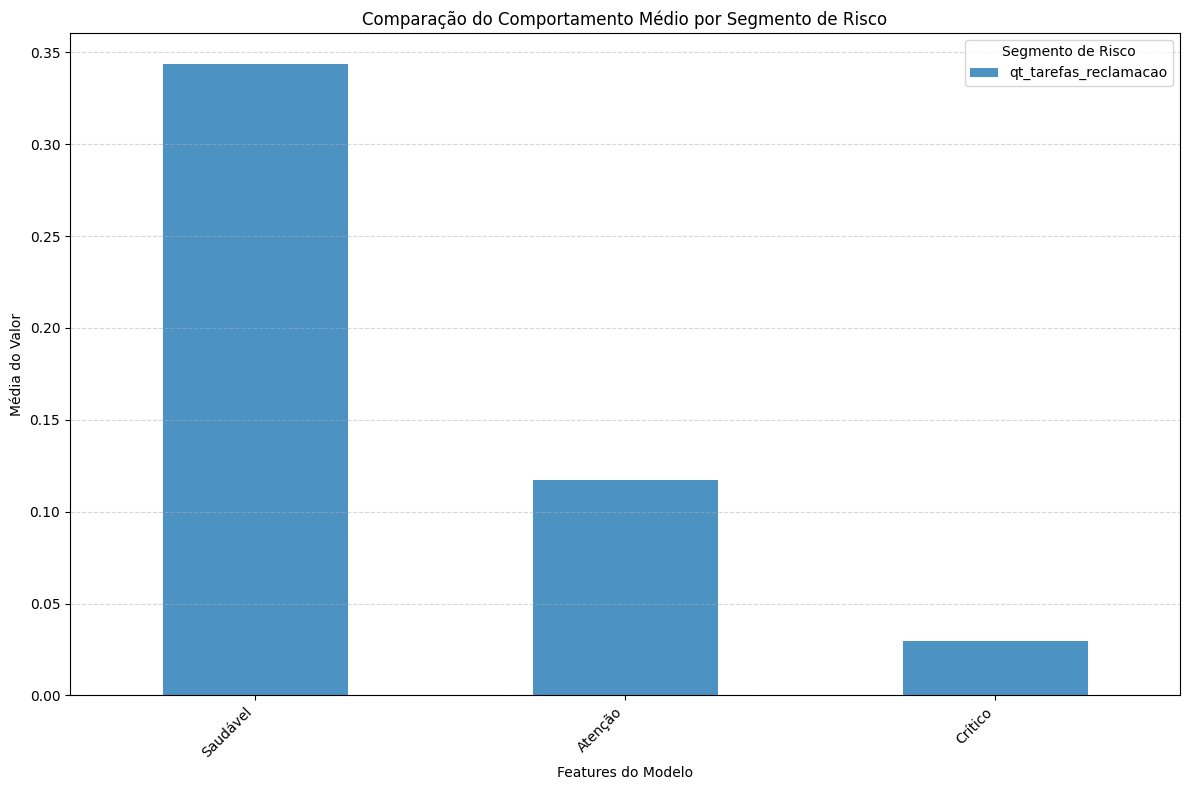

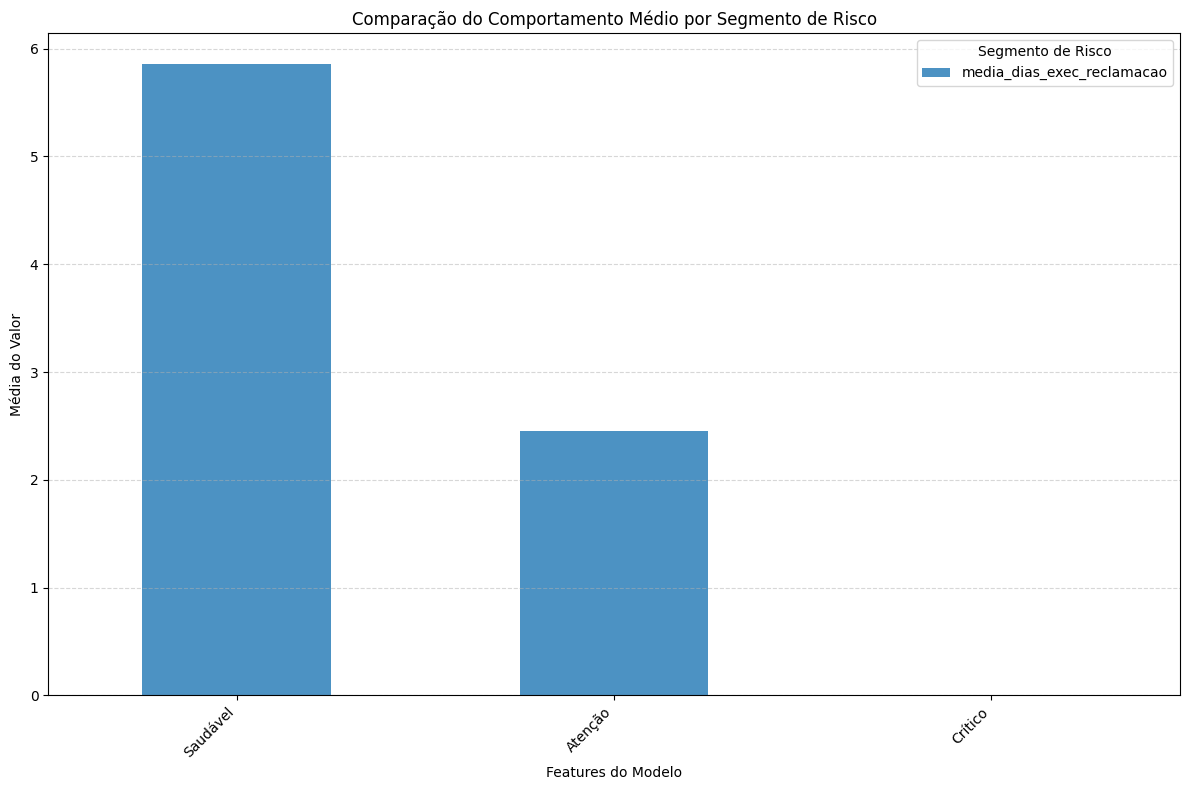

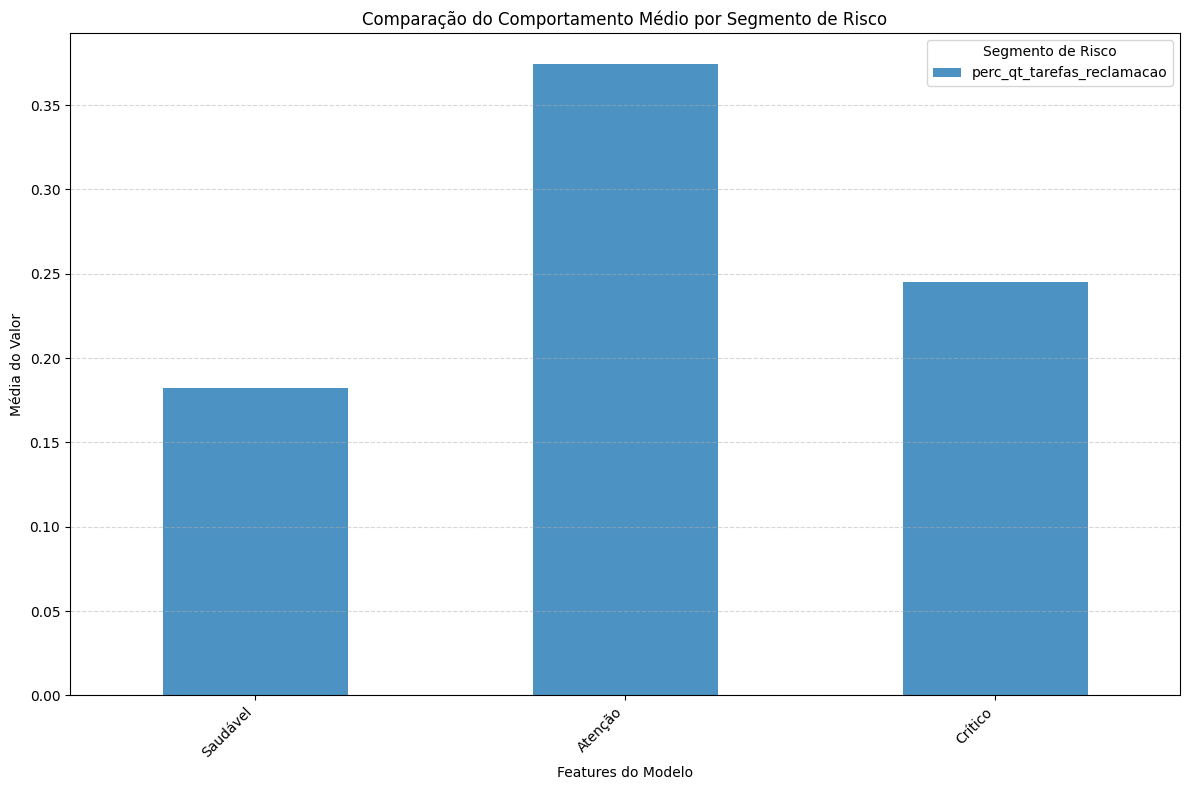

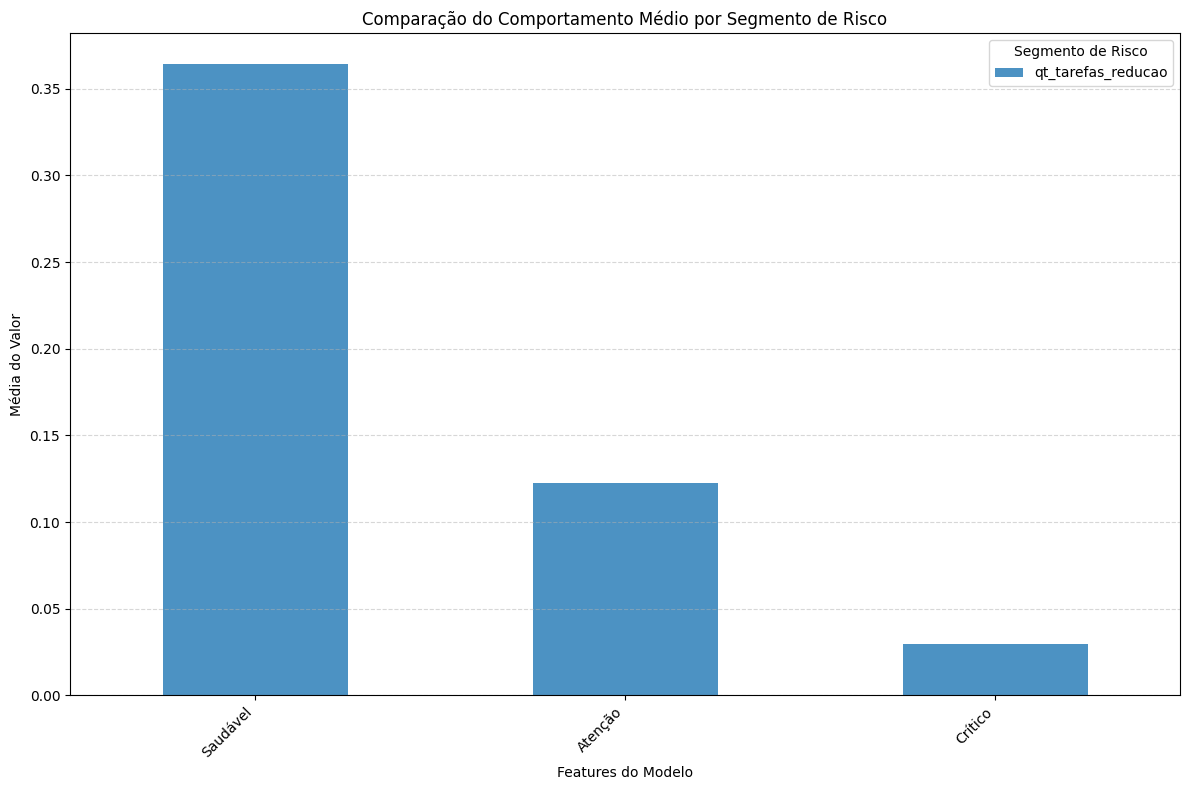

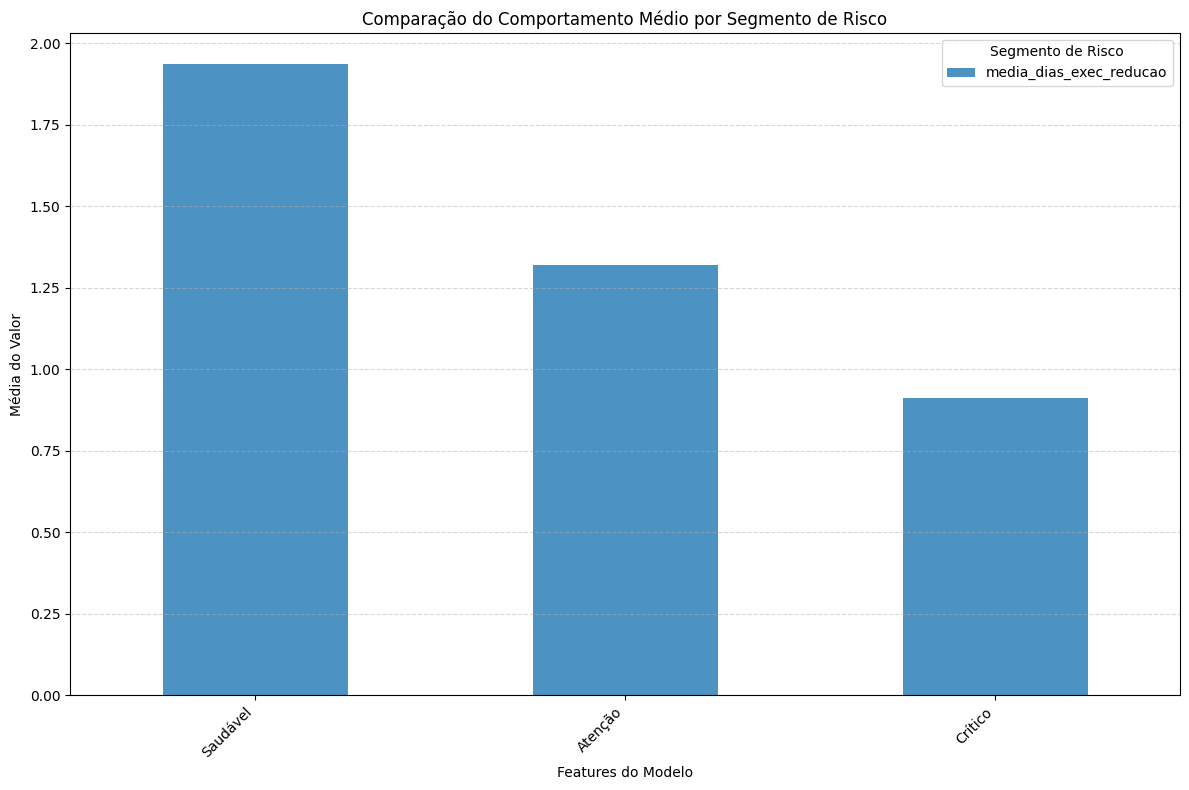

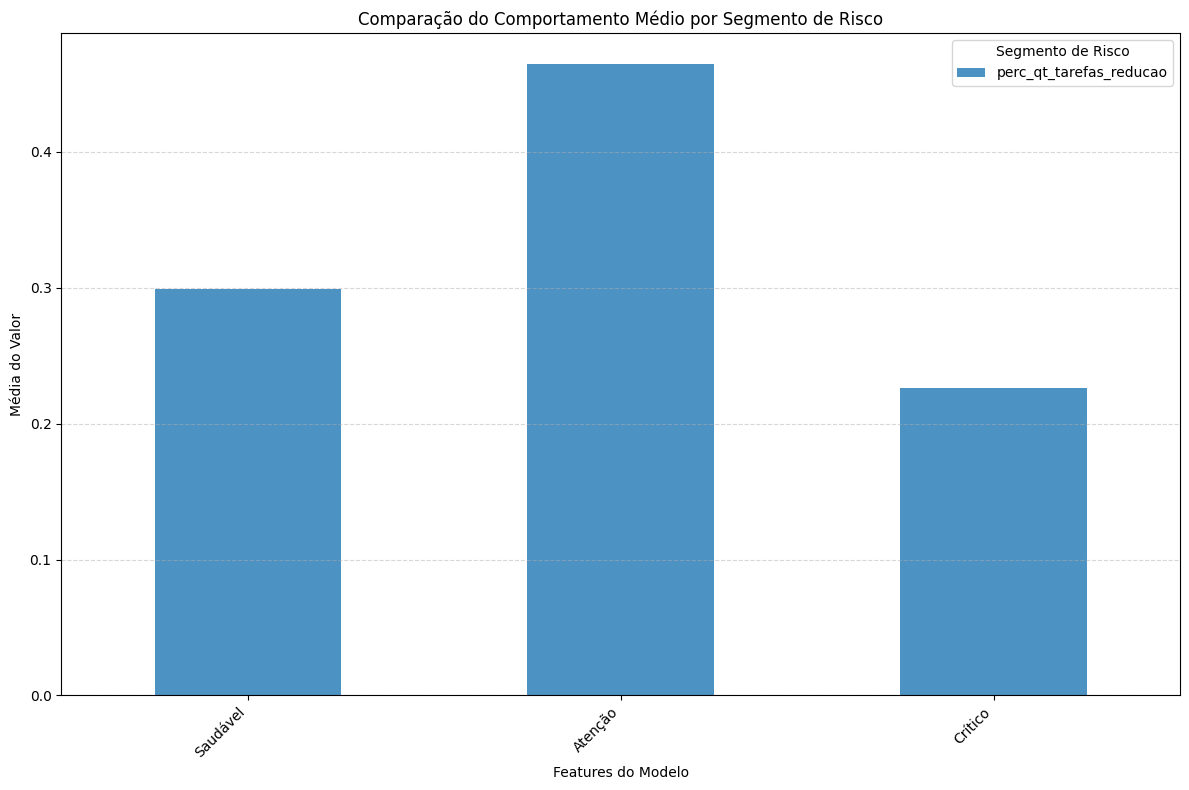

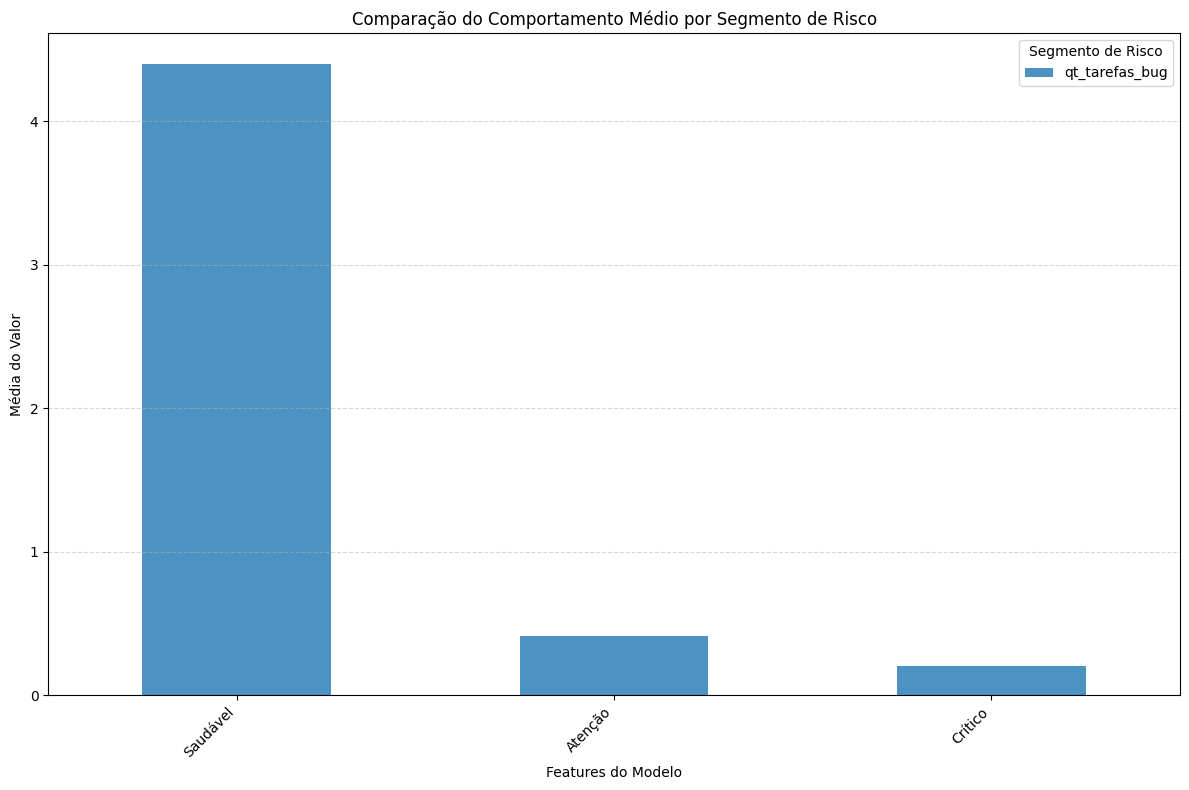

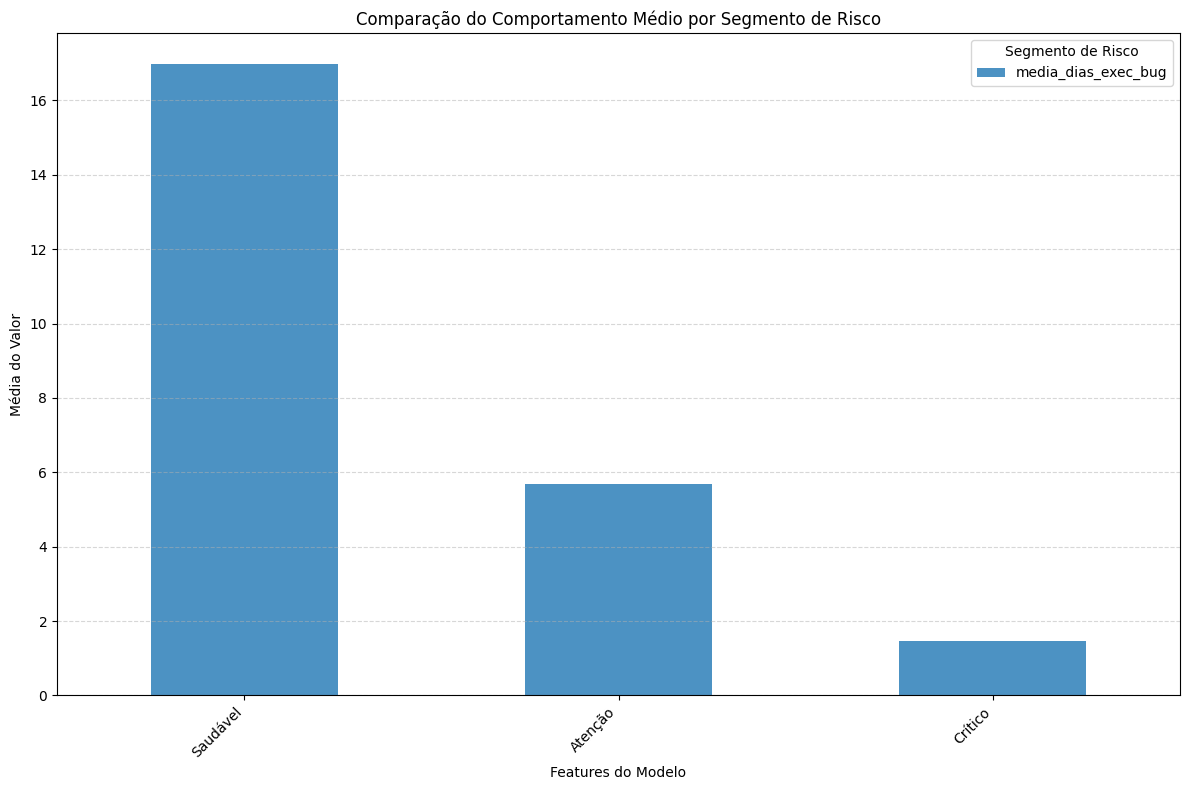

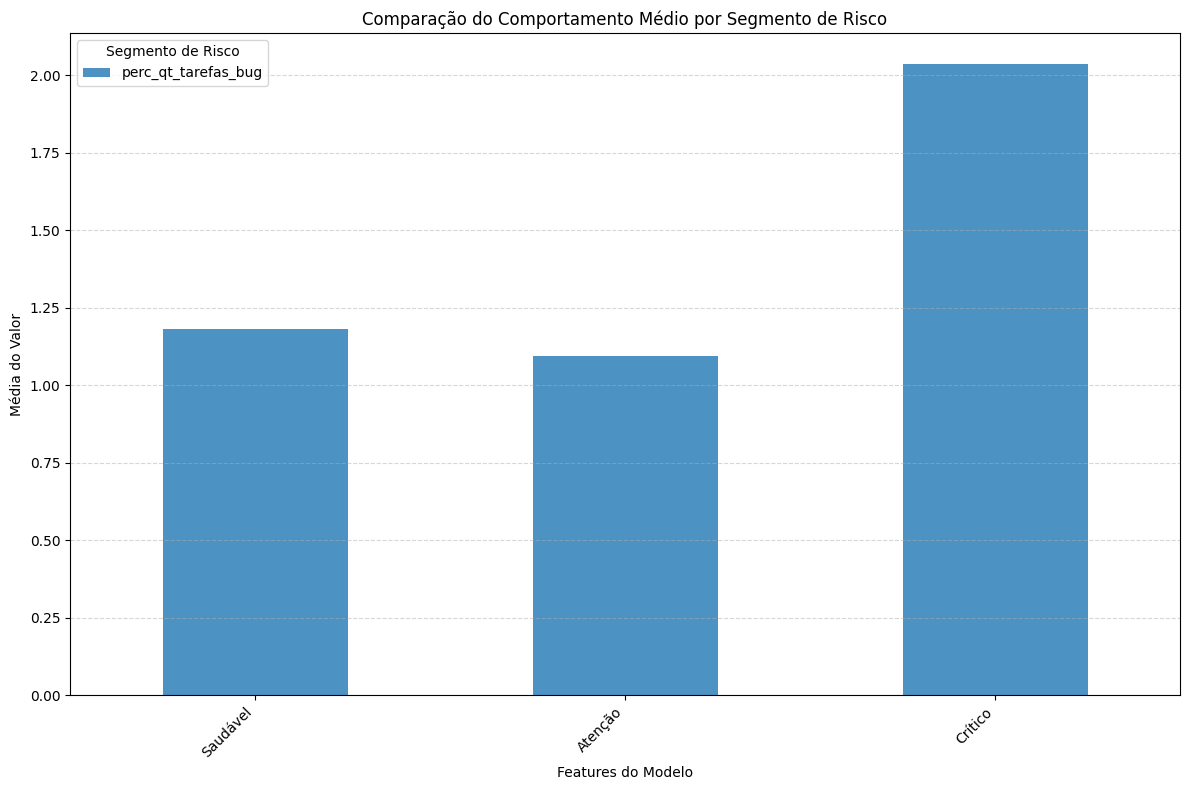

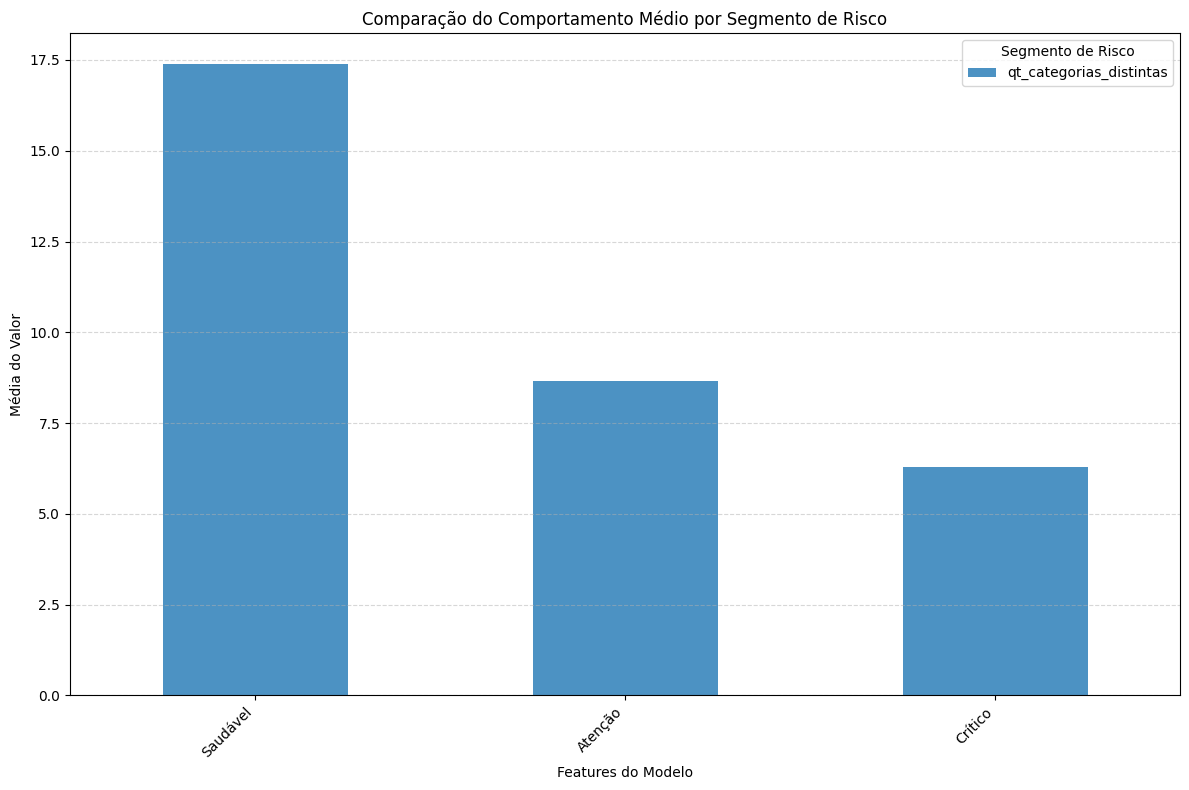

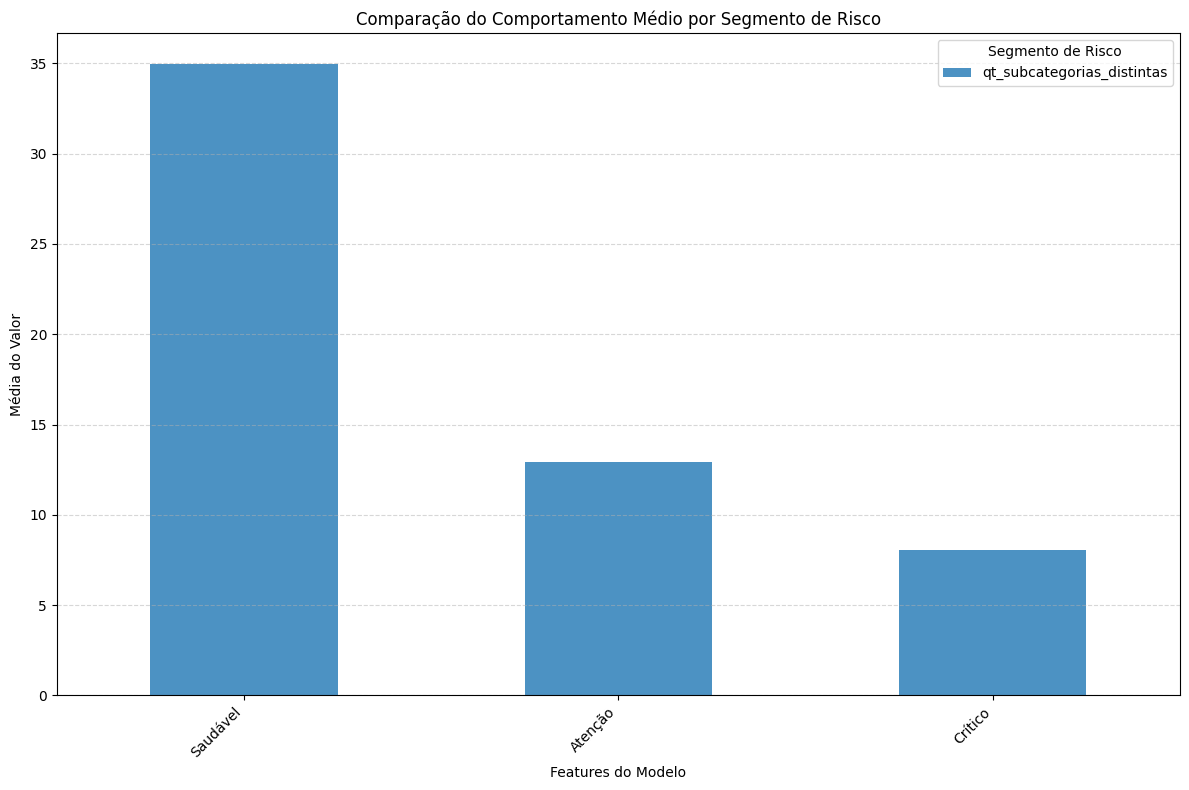

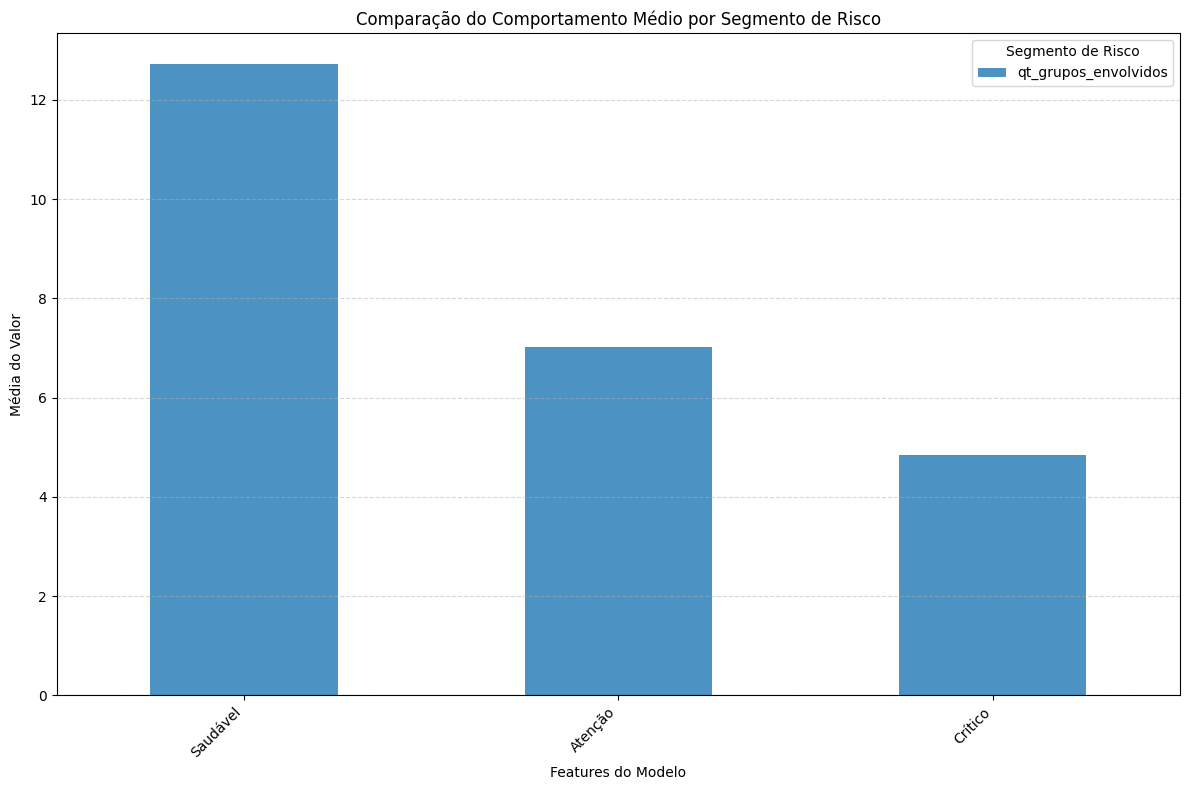

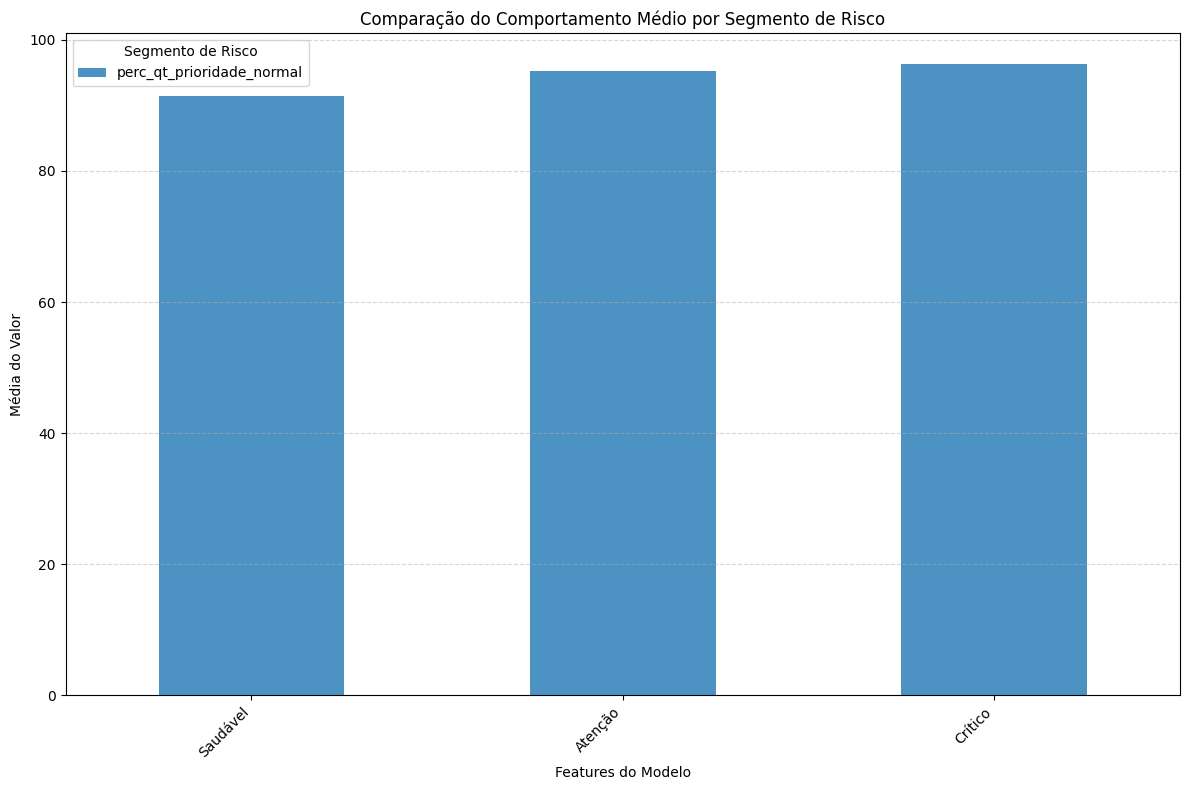

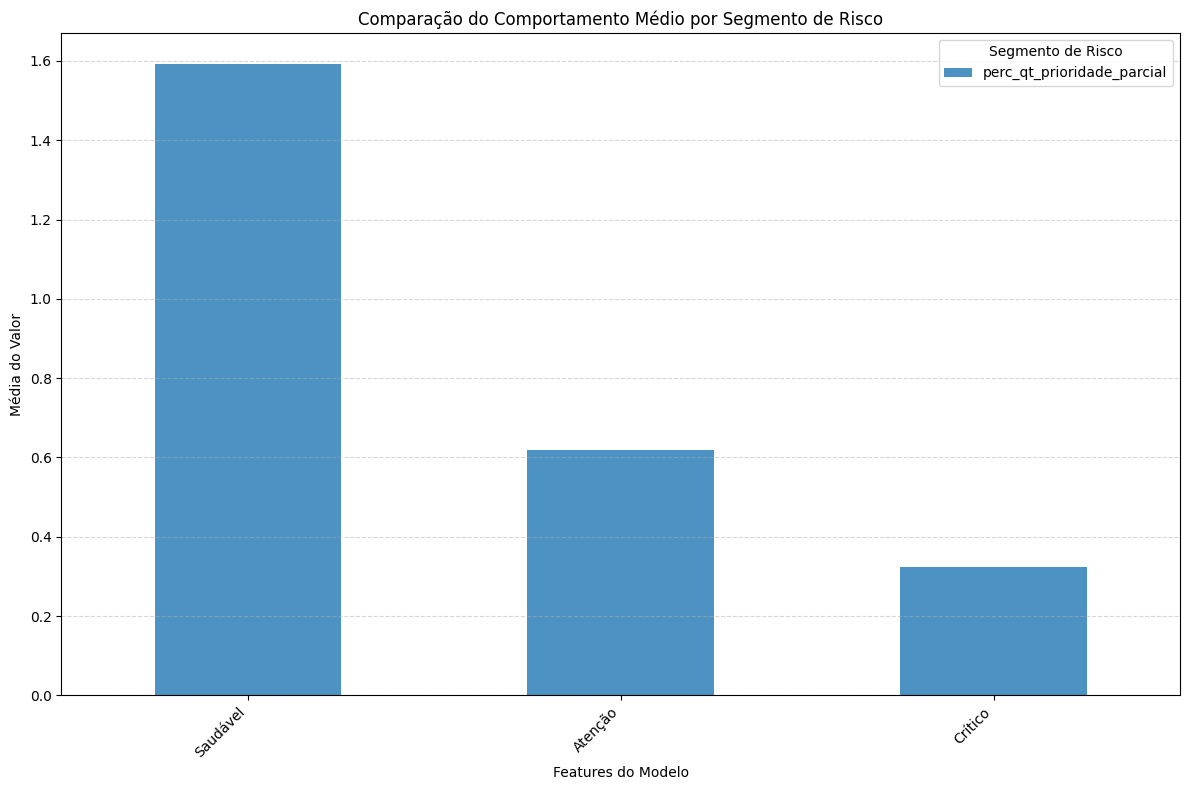

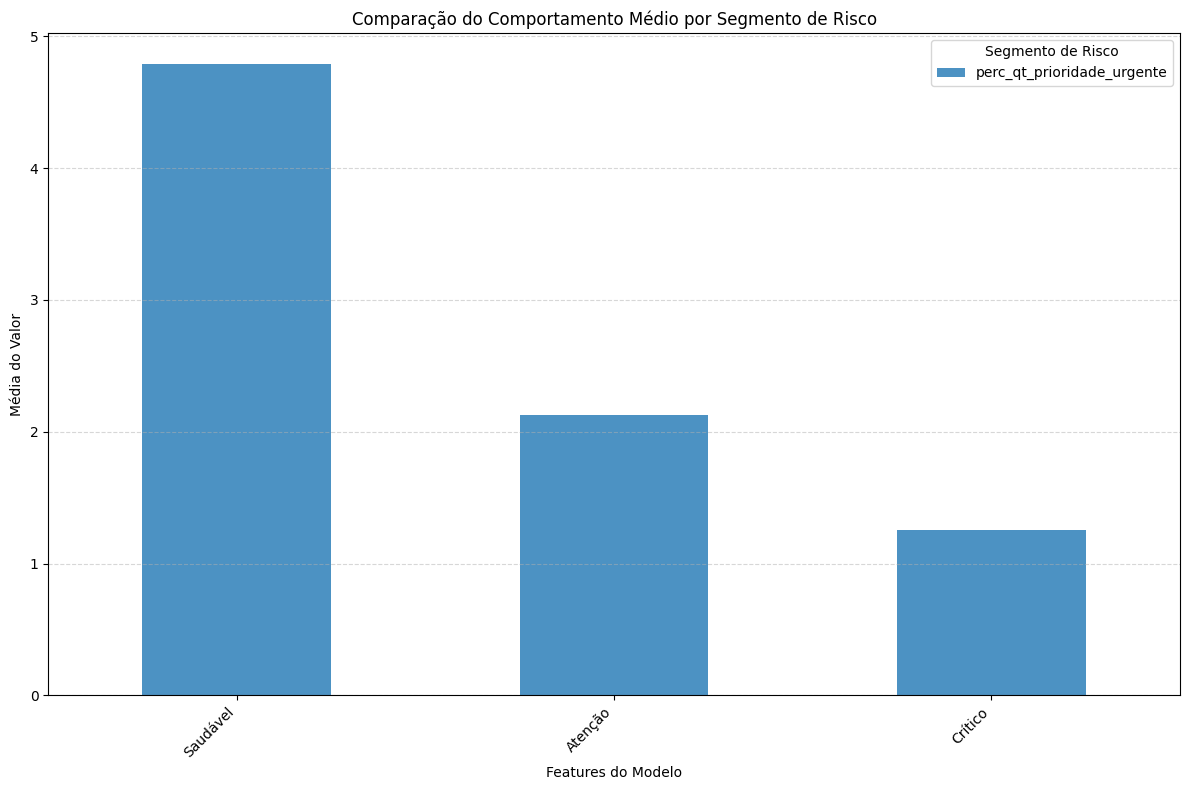

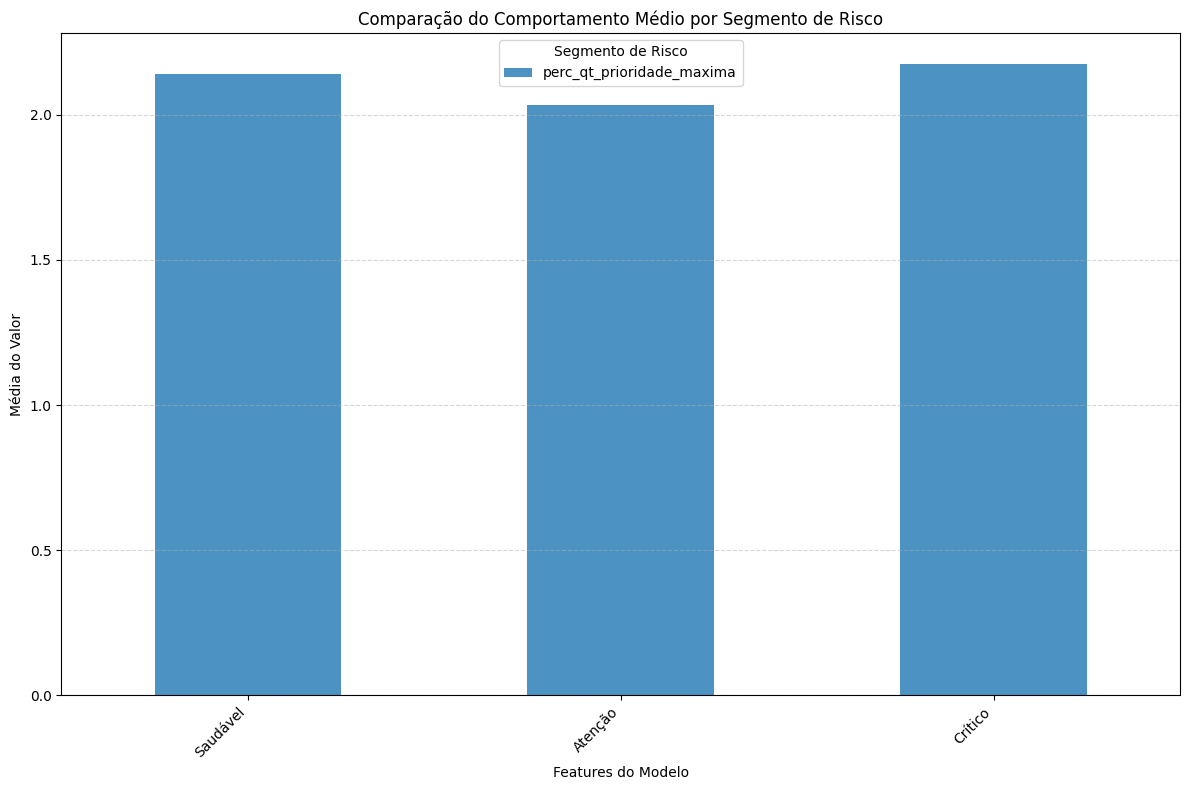

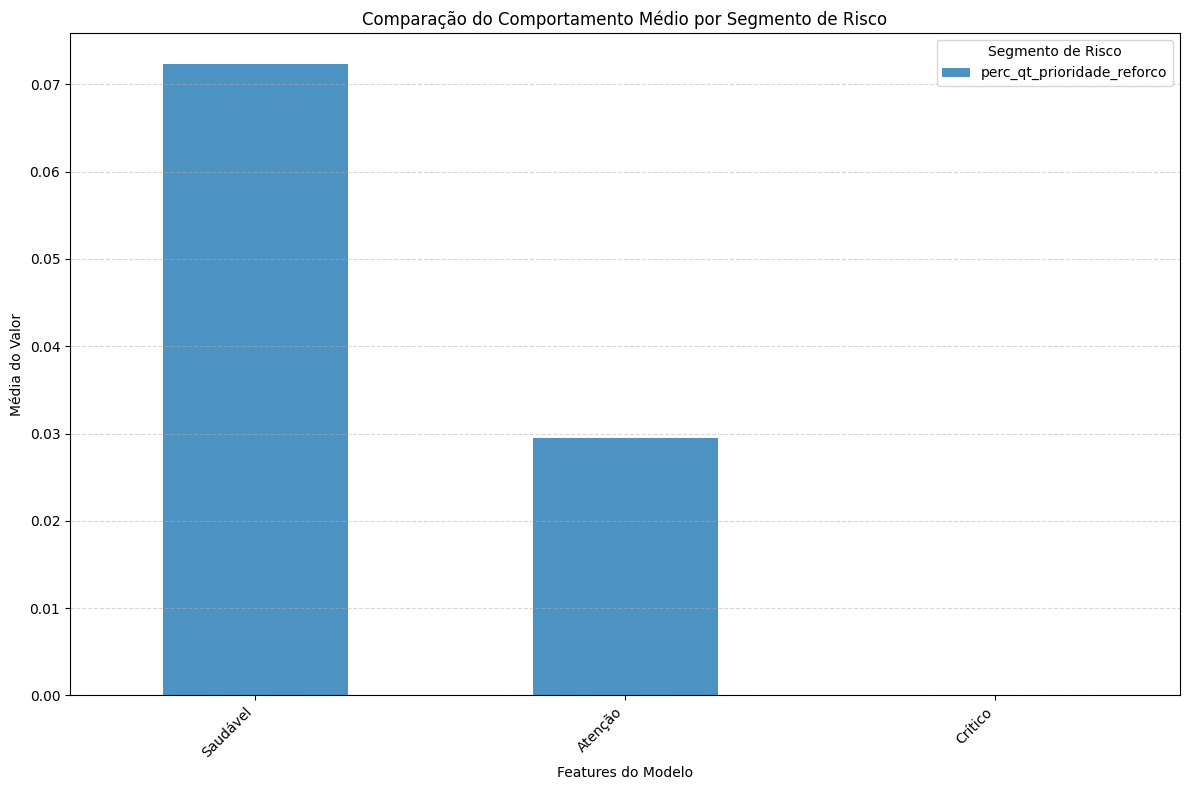

In [46]:
# 2. Definir as colunas que você quer comparar (removendo colunas não numéricas)
# O drop remove as colunas que não são métricas comportamentais
cols_to_plot = df_preds.drop(columns=['cod_cliente', 'churn', 'risco_churn_percentual', 'segmento_risco']).columns

# 3. Agrupar por segmento de risco e calcular a média
# O 'observed=True' garante que ele pegue apenas as categorias presentes
for col in cols_to_plot:
    df_preds_medias = df_preds.groupby('segmento_risco', observed=True)[col].mean().T

    df_preds_medias.plot(kind='bar', figsize=(12, 8), alpha=0.8)

    plt.title('Comparação do Comportamento Médio por Segmento de Risco', fontsize=12)
    plt.ylabel('Média do Valor')
    plt.xlabel('Features do Modelo')
    plt.legend(title='Segmento de Risco')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()